### **PROJECT : Use of ANN to Predicting Hotel Booking Cancellations**

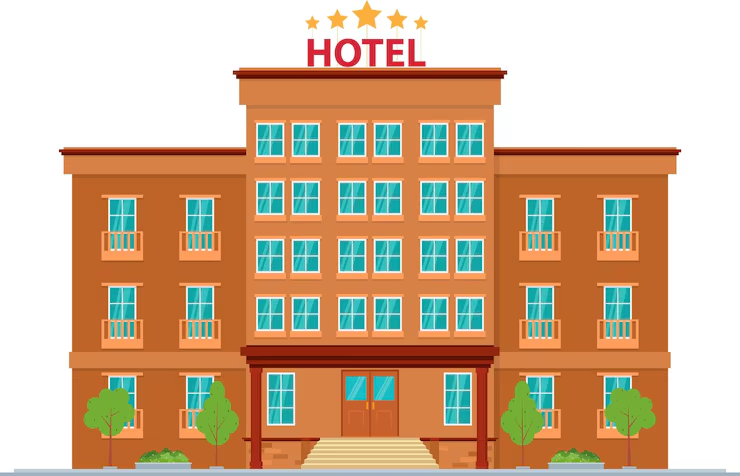

### **PHASE 1 : Load the Data**

In [1]:
import pandas as pd

In [2]:
data = pd.read_csv("hotel_bookings.csv")
data.head()

,index,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,0,Resort Hotel,0,342,2015,July,27,1,0,0,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,01-07-15
1,1,Resort Hotel,0,737,2015,July,27,1,0,0,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,01-07-15
2,2,Resort Hotel,0,7,2015,July,27,1,0,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,02-07-15
3,3,Resort Hotel,0,13,2015,July,27,1,0,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,02-07-15
4,4,Resort Hotel,0,14,2015,July,27,1,0,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,03-07-15


### **PHASE 2 : Understand the Data (EDA)**
* Number of rows : 119390
* Number of columns : 33
* Missing Values : Yes
* Duplicate rows : No
* Outliers : Yes
* Unecessary features : Yes

In [3]:
data.shape

(119390, 33)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 33 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   index                           119390 non-null  int64  
 1   hotel                           119390 non-null  object 
 2   is_canceled                     119390 non-null  int64  
 3   lead_time                       119390 non-null  int64  
 4   arrival_date_year               119390 non-null  int64  
 5   arrival_date_month              119390 non-null  object 
 6   arrival_date_week_number        119390 non-null  int64  
 7   arrival_date_day_of_month       119390 non-null  int64  
 8   stays_in_weekend_nights         119390 non-null  int64  
 9   stays_in_week_nights            119390 non-null  int64  
 10  adults                          119390 non-null  int64  
 11  children                        119386 non-null  float64
 12  babies          

In [5]:
data.describe(include='all')

,index,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
count,119390.000000,119390,119390.000000,119390.000000,119390.000000,119390,119390.000000,119390.000000,119390.000000,119390.000000,...,119390,103050.000000,6797.000000,119390.000000,119390,119390.000000,119390.000000,119390.000000,119390,119390
unique,NaN,2,NaN,NaN,NaN,12,NaN,NaN,NaN,NaN,...,3,NaN,NaN,NaN,4,NaN,NaN,NaN,3,926
top,NaN,City Hotel,NaN,NaN,NaN,August,NaN,NaN,NaN,NaN,...,No Deposit,NaN,NaN,NaN,Transient,NaN,NaN,NaN,Check-Out,21-10-15
freq,NaN,79330,NaN,NaN,NaN,13877,NaN,NaN,NaN,NaN,...,104641,NaN,NaN,NaN,89613,NaN,NaN,NaN,75166,1461
mean,59694.500000,NaN,0.370416,104.011416,2016.156554,NaN,27.165173,15.798241,0.927599,2.500302,...,NaN,86.693382,189.266735,2.321149,NaN,101.831122,0.062518,0.571363,NaN,NaN
std,34465.068657,NaN,0.482918,106.863097,0.707476,NaN,13.605138,8.780829,0.998613,1.908286,...,NaN,110.774548,131.655015,17.594721,NaN,50.535790,0.245291,0.792798,NaN,NaN
min,0.000000,NaN,0.000000,0.000000,2015.000000,NaN,1.000000,1.000000,0.000000,0.000000,...,NaN,1.000000,6.000000,0.000000,NaN,-6.380000,0.000000,0.000000,NaN,NaN
25%,29847.250000,NaN,0.000000,18.000000,2016.000000,NaN,16.000000,8.000000,0.000000,1.000000,...,NaN,9.000000,62.000000,0.000000,NaN,69.290000,0.000000,0.000000,NaN,NaN
50%,59694.500000,NaN,0.000000,69.000000,2016.000000,NaN,28.000000,16.000000,1.000000,2.000000,...,NaN,14.000000,179.000000,0.000000,NaN,94.575000,0.000000,0.000000,NaN,NaN
75%,89541.750000,NaN,1.000000,160.000000,2017.000000,NaN,38.000000,23.000000,2.000000,3.000000,...,NaN,229.000000,270.000000,0.000000,NaN,126.000000,0.000000,1.000000,NaN,NaN


In [6]:
data.isnull().sum()

,0
index,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0


In [7]:
data.duplicated().sum()

np.int64(0)

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

119389
0


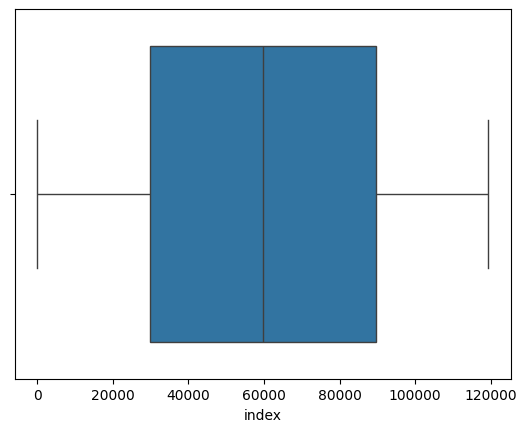

In [9]:
print(data['index'].max())
print(data['index'].min())
sns.boxplot(data=data,x='index')
plt.show()

In [10]:
data['is_canceled'].value_counts() ### Target Column

,count
is_canceled,
0,75166
1,44224


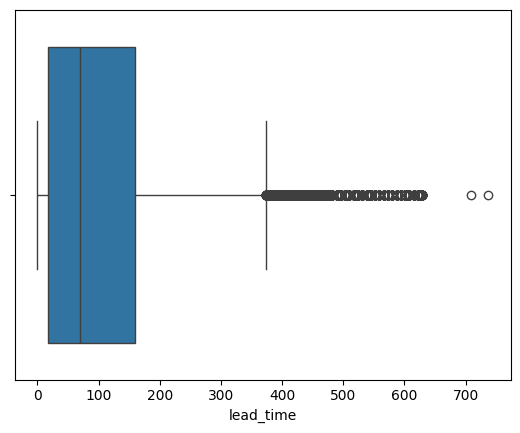

In [11]:
sns.boxplot(data=data,x='lead_time')
plt.show()

In [12]:
data['arrival_date_year'].value_counts()

,count
arrival_date_year,
2016,56707
2017,40687
2015,21996


53
1


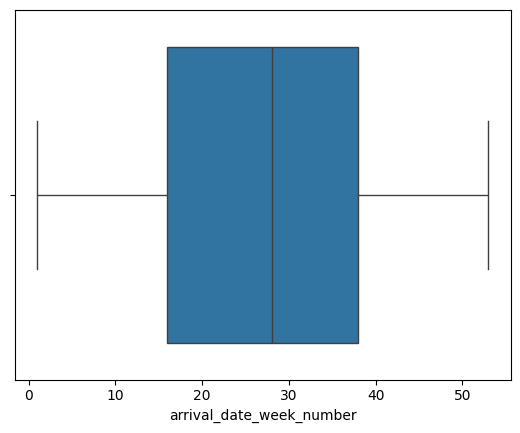

In [13]:
print(data['arrival_date_week_number'].max())
print(data['arrival_date_week_number'].min())
sns.boxplot(data=data,x='arrival_date_week_number')
plt.show()

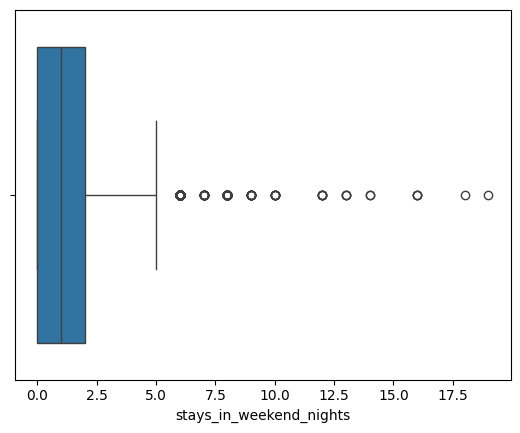

In [14]:
sns.boxplot(data=data,x='stays_in_weekend_nights')
plt.show()

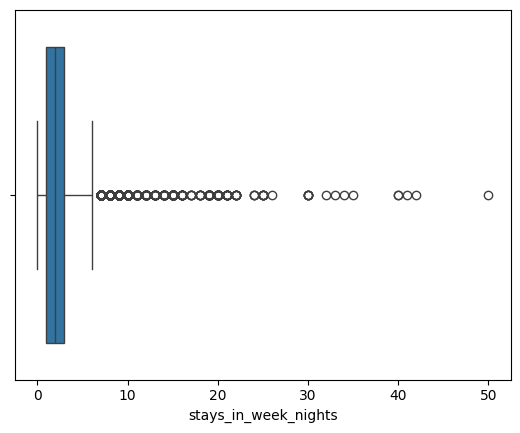

In [15]:
sns.boxplot(data=data,x='stays_in_week_nights')
plt.show()

In [16]:
data['adults'].value_counts()

,count
adults,
2,89680
1,23027
3,6202
0,403
4,62
26,5
5,2
27,2
20,2


In [17]:
data['children'].value_counts()

,count
children,
0.0,110796
1.0,4861
2.0,3652
3.0,76
10.0,1


In [18]:
data['babies'].value_counts()

,count
babies,
0,118473
1,900
2,15
10,1
9,1


In [19]:
data['is_repeated_guest'].value_counts()

,count
is_repeated_guest,
0,115580
1,3810


In [20]:
data['previous_cancellations'].value_counts().sort_index()

,count
previous_cancellations,
0,112906
1,6051
2,116
3,65
4,31
5,19
6,22
11,35
13,12


In [21]:
data['previous_bookings_not_canceled'].value_counts().sort_index()

,count
previous_bookings_not_canceled,
0,115770
1,1542
2,580
3,333
4,229
...,...
68,1
69,1
70,1


In [22]:
data['booking_changes'].value_counts()

,count
booking_changes,
0,101314
1,12701
2,3805
3,927
4,376
5,118
6,63
7,31
8,17


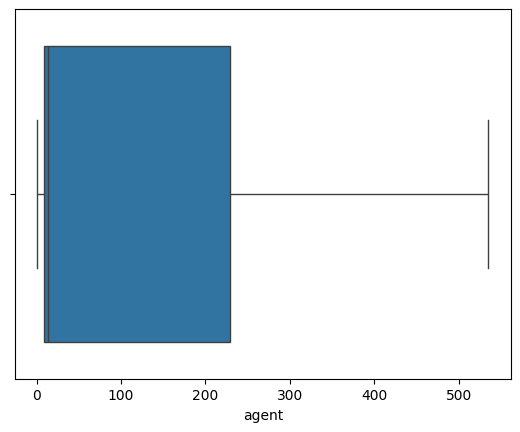

In [23]:
sns.boxplot(data=data,x='agent')
plt.show()

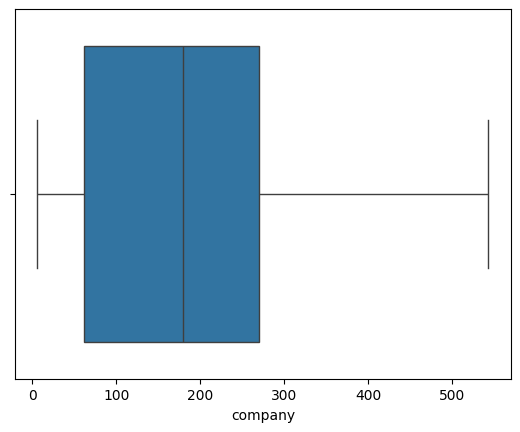

In [24]:
sns.boxplot(data=data,x='company')
plt.show()

In [25]:
data['days_in_waiting_list'].value_counts()

,count
days_in_waiting_list,
0,115692
39,227
58,164
44,141
31,127
...,...
81,1
92,1
74,1


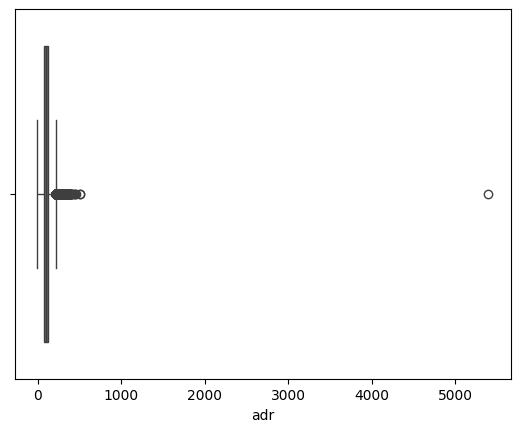

In [26]:
sns.boxplot(data=data,x='adr')
plt.show()

In [27]:
data['required_car_parking_spaces'].value_counts()

,count
required_car_parking_spaces,
0,111974
1,7383
2,28
3,3
8,2


In [28]:
data['total_of_special_requests'].value_counts()

,count
total_of_special_requests,
0,70318
1,33226
2,12969
3,2497
4,340
5,40


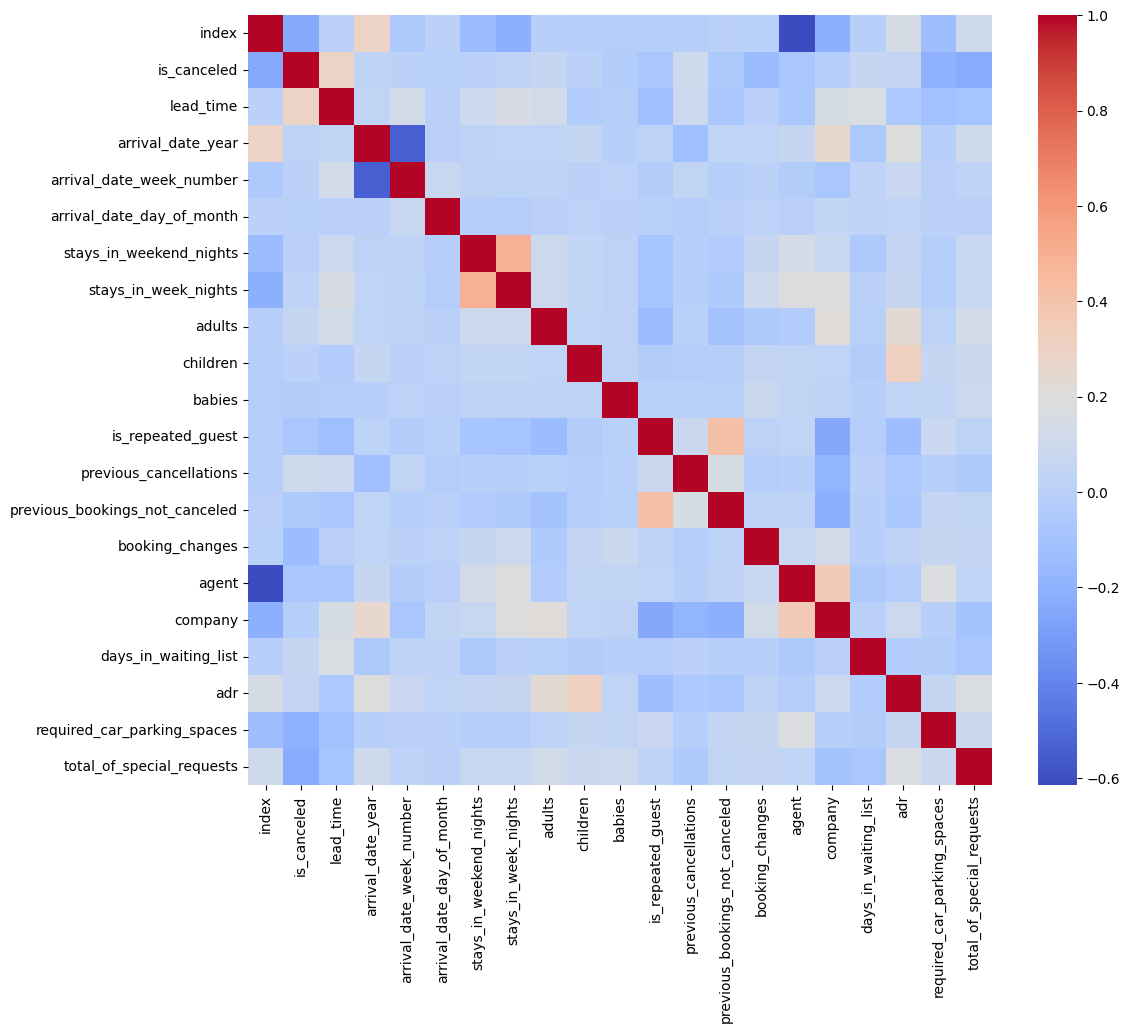

In [29]:
corr = data.corr(numeric_only=True)
plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap="coolwarm")
plt.show()

* hotel: The type of hotel (Categorical)
* is_canceled: Indicates whether the booking was canceled (Binary)
* lead_time: The number of days between the booking date and the arrival date (Numerical)
* arrival_date_year: The year of the arrival date (Numerical)
* arrival_date_month: The month of the arrival date (Categorical)
* arrival_date_week_number: The week number of the arrival date (Numerical)
* arrival_date_day_of_month: The day of the month of the arrival date (Numerical)
* stays_in_weekend_nights: The number of weekend nights (Saturday and Sunday) the guest stayed or booked to stay at the hotel (Numerical)
* stays_in_week_nights: The number of weeknights (Monday to Friday) the guest stayed or booked to stay at the hotel (Numerical)
* adults: The number of adults included in the booking (Numerical)
* children: The number of children included in the booking (Numerical)
* babies: The number of babies included in the booking (Numerical)
* meal: The type of meal booked (Categorical)
* country: The country of origin for each guest who made a reservation (Categorical)
* market_segment: The market segment that individuals belong to when making reservations (Categorical)
* distribution_channel: The channel through which bookings were made (Categorical)
* is_repeated_guest: Indicates whether the guest is a repeated visitor (Binary)
* previous_cancellations: The number of times guests previously canceled their bookings (Numerical)
* previous_bookings_not_canceled: The count of previous bookings made by guests that were not canceled (Numerical)
* reserved_room_type: The type of room initially reserved (Categorical)
* assigned_room_type: The type of room that was assigned to guests. (Categorical) X
* booking_changes: The number of changes made to the booking. (Numerical)
* deposit_type: The type of deposit made for the booking. (Categorical)
* agent: The ID of the travel agency that made the booking. (Categorical)
* company: The ID of the company that made the booking. (Categorical)
* days_in_waiting_list: The number of days the booking was on the waiting list before being confirmed. (Numerical)
* customer_type: The type of customer (e.g., transient, contract, group, or other). (Categorical)
* adr: The average daily rate (price per room) for the booking. (Numerical)
* required_car_parking_spaces: The number of car parking spaces required by the guest. (Numerical)
* total_of_special_requests: The total number of special requests made by the guest (e.g., extra bed, room amenities). (Numerical)
* reservation_status: The status of the reservation (e.g., canceled, checked-in, no-show). (Categorical) X
* reservation_status_date: The date on which the reservation status was last updated. (Date) X

### **PHASE 3 : Data Cleaning**

1) Handling missing values

children

In [30]:
data['children'].isnull().sum()

np.int64(4)

In [31]:
data['children'] = data['children'].fillna(0)
data['children'].isnull().sum()

np.int64(0)

In [32]:
data['children'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 119390 entries, 0 to 119389
Series name: children
Non-Null Count   Dtype  
--------------   -----  
119390 non-null  float64
dtypes: float64(1)
memory usage: 932.9 KB


country

In [33]:
data['country'].isnull().sum()

np.int64(488)

In [34]:
data.shape

(119390, 33)

In [35]:
data = data.dropna(subset=['country'])
data.shape

(118902, 33)

agent and company

In [36]:
print(data['agent'].isnull().sum())
print(data['company'].isnull().sum())

16006
112279


In [37]:
data['agent'] = data['agent'].fillna(0)
data['company'] = data['company'].fillna(0)

In [38]:
print(data['agent'].isnull().sum())
print(data['company'].isnull().sum())

0
0


data After handling missing values





In [39]:
data.shape

(118902, 33)

In [40]:
data.isnull().sum().sum()

np.int64(0)

2) Handling outliers

In [41]:
### Outliers do exist, but they look like natural, genuine variations - so keeping it untouched

### **PHASE 4 : Feature Engineering**

Removing unnecessary features

In [42]:
data = data.drop(columns=['assigned_room_type','reservation_status','reservation_status_date'])
print(data.shape)
data.head()

(118902, 30)


,index,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,...,reserved_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
0,0,Resort Hotel,0,342,2015,July,27,1,0,0,...,C,3,No Deposit,0.0,0.0,0,Transient,0.0,0,0
1,1,Resort Hotel,0,737,2015,July,27,1,0,0,...,C,4,No Deposit,0.0,0.0,0,Transient,0.0,0,0
2,2,Resort Hotel,0,7,2015,July,27,1,0,1,...,A,0,No Deposit,0.0,0.0,0,Transient,75.0,0,0
3,3,Resort Hotel,0,13,2015,July,27,1,0,1,...,A,0,No Deposit,304.0,0.0,0,Transient,75.0,0,0
4,4,Resort Hotel,0,14,2015,July,27,1,0,2,...,A,0,No Deposit,240.0,0.0,0,Transient,98.0,0,1


Encoding and Scaling

In [43]:
data.drop(columns='index', inplace=True)

In [44]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 118902 entries, 0 to 119389
Data columns (total 29 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           118902 non-null  object 
 1   is_canceled                     118902 non-null  int64  
 2   lead_time                       118902 non-null  int64  
 3   arrival_date_year               118902 non-null  int64  
 4   arrival_date_month              118902 non-null  object 
 5   arrival_date_week_number        118902 non-null  int64  
 6   arrival_date_day_of_month       118902 non-null  int64  
 7   stays_in_weekend_nights         118902 non-null  int64  
 8   stays_in_week_nights            118902 non-null  int64  
 9   adults                          118902 non-null  int64  
 10  children                        118902 non-null  float64
 11  babies                          118902 non-null  int64  
 12  meal                 

In [45]:
text_cols = ['hotel','arrival_date_month','meal',
             'country','market_segment','distribution_channel',
             'reserved_room_type','deposit_type','customer_type']
num_cols = ['lead_time','arrival_date_year','arrival_date_week_number',
            'arrival_date_day_of_month','stays_in_weekend_nights',
            'stays_in_week_nights','adults','children','babies',
            'previous_cancellations','previous_bookings_not_canceled',
            'booking_changes','agent','company','days_in_waiting_list',
            'adr','required_car_parking_spaces','total_of_special_requests']

In [46]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
preprocessor = ColumnTransformer(
    transformers = [
        ('ohe',OneHotEncoder(handle_unknown='ignore', sparse_output=False),text_cols),
        ('ss',StandardScaler(),num_cols)
    ], remainder = 'passthrough'
)
transformed = preprocessor.fit_transform(data)
data = pd.DataFrame(transformed,columns=preprocessor.get_feature_names_out(),index=data.index)
data.head()

,ohe__hotel_City Hotel,ohe__hotel_Resort Hotel,ohe__arrival_date_month_April,ohe__arrival_date_month_August,ohe__arrival_date_month_December,ohe__arrival_date_month_February,ohe__arrival_date_month_January,ohe__arrival_date_month_July,ohe__arrival_date_month_June,ohe__arrival_date_month_March,...,ss__previous_bookings_not_canceled,ss__booking_changes,ss__agent,ss__company,ss__days_in_waiting_list,ss__adr,ss__required_car_parking_spaces,ss__total_of_special_requests,remainder__is_canceled,remainder__is_repeated_guest
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,-0.088661,4.256959,-0.699001,-0.197383,-0.132199,-2.020346,-0.253445,-0.721236,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,-0.088661,5.788886,-0.699001,-0.197383,-0.132199,-2.020346,-0.253445,-0.721236,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,-0.088661,-0.338822,-0.699001,-0.197383,-0.132199,-0.534809,-0.253445,-0.721236,0.0,0.0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,-0.088661,-0.338822,2.138295,-0.197383,-0.132199,-0.534809,-0.253445,-0.721236,0.0,0.0
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,-0.088661,-0.338822,1.540970,-0.197383,-0.132199,-0.079245,-0.253445,0.540315,0.0,0.0


In [47]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 118902 entries, 0 to 119389
Columns: 246 entries, ohe__hotel_City Hotel to remainder__is_repeated_guest
dtypes: float64(246)
memory usage: 224.1 MB


### **PHASE 5 : Split dataset ( random_split )**

In [48]:
import torch

In [49]:
from torch.utils.data import Dataset,random_split,DataLoader

In [50]:
class DS(Dataset):
  def __init__(self):
    self.x = torch.tensor(data.drop(columns='remainder__is_canceled').values,dtype=torch.float32)
    self.y = torch.tensor(data['remainder__is_canceled'].values,dtype=torch.float32).unsqueeze(1)
  def __len__(self):
    return len(self.x)
  def __getitem__(self,index):
    return self.x[index],self.y[index]
dataset = DS()

In [51]:
train,valid,test = random_split(dataset,[0.8,0.1,0.1])
train_loader = DataLoader(train,batch_size=10000,shuffle=True)
valid_loader = DataLoader(valid,batch_size=3000,shuffle=False)
test_loader = DataLoader(test,batch_size=3000,shuffle=False)

### **PHASE 6 : Model Building**

In [52]:
print(dataset.x.shape)
print(dataset.y.shape)
print(len(train_loader))
print(len(valid_loader))
print(len(test_loader))

torch.Size([118902, 245])
torch.Size([118902, 1])
10
4
4


In [53]:
import torch
import torch.nn as nn
class ann(nn.Module):
  def __init__(self):
    super().__init__()
    self.fc1 = nn.Linear(245,128)
    self.relu = nn.ReLU()
    self.fc2 = nn.Linear(128,64)
    self.fc3 = nn.Linear(64,1)
  def forward(self,x):
    x = self.fc1(x)
    x = self.relu(x)
    x = self.fc2(x)
    x = self.relu(x)
    x = self.fc3(x)
    return x
model = ann()
bce = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model.parameters(),lr=0.01)

### **PHASE 7 : Model Training**

In [54]:
num_epochs = 10000
best_valid_loss = float("inf")
patience = 5
counter = 0

for epoch in range(num_epochs):
  model.train()
  train_loss = 0
  for inputs,outputs in train_loader:
    optimizer.zero_grad()
    prediction = model(inputs)
    loss = bce(prediction,outputs)
    loss.backward()
    optimizer.step()
    train_loss += loss.item()
  train_loss /= len(train_loader)

  model.eval()
  valid_loss = 0
  with torch.no_grad():
    for inputs,outputs in valid_loader:
      prediction = model(inputs)
      loss = bce(prediction,outputs)
      valid_loss += loss.item()
  valid_loss /= len(valid_loader)
  if valid_loss < best_valid_loss :
    best_valid_loss = valid_loss
    counter = 0
  else :
    counter += 1
  if counter >= patience:
    print("Early stopping Triggered !")
    break
  print("-"*60)
  print(f"Epoch[{epoch+1}/{num_epochs}]")
  print(f"Train Loss : {train_loss:.4f}")
  print(f"Valid Loss : {valid_loss:.4f}")

Streaming output truncated to the last 5000 lines.
Epoch[1530/10000]
Train Loss : 0.3202
Valid Loss : 0.3140
------------------------------------------------------------
Epoch[1531/10000]
Train Loss : 0.3202
Valid Loss : 0.3140
------------------------------------------------------------
Epoch[1532/10000]
Train Loss : 0.3199
Valid Loss : 0.3139
------------------------------------------------------------
Epoch[1533/10000]
Train Loss : 0.3201
Valid Loss : 0.3139
------------------------------------------------------------
Epoch[1534/10000]
Train Loss : 0.3206
Valid Loss : 0.3139
------------------------------------------------------------
Epoch[1535/10000]
Train Loss : 0.3201
Valid Loss : 0.3139
------------------------------------------------------------
Epoch[1536/10000]
Train Loss : 0.3198
Valid Loss : 0.3138
------------------------------------------------------------
Epoch[1537/10000]
Train Loss : 0.3199
Valid Loss : 0.3138
----------------------------------------------------------

### **PHASE 8 : Model Evaluation**

In [56]:
model.eval()
test_loss = 0
y_true = []
y_pred = []
with torch.no_grad():
  for inputs,outputs in test_loader:
    prediction = model(inputs)
    loss = bce(prediction,outputs)
    test_loss += loss.item()
    predicted = (prediction>=0.5).float()
    y_true.extend(outputs.numpy())
    y_pred.extend(predicted.numpy())
avg_test_loss = test_loss/len(test_loader)

In [57]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix

In [58]:
print("Test Loss :",avg_test_loss)
print("Accuracy :",accuracy_score(y_true,y_pred))
print("Precision :",precision_score(y_true,y_pred))
print("Recall :",recall_score(y_true,y_pred))
print("F1 Score :",f1_score(y_true,y_pred))
print("Confusion Matrix :",confusion_matrix(y_true,y_pred))

Test Loss : 0.3005649670958519
Accuracy : 0.8513036164844408
Precision : 0.9142259414225942
Recall : 0.6737885462555067
F1 Score : 0.7758052244483895
Confusion Matrix : [[7063  287]
 [1481 3059]]


In [59]:
from sklearn.metrics import classification_report
print("Classification report :",classification_report(y_true,y_pred))

Classification report :               precision    recall  f1-score   support

         0.0       0.83      0.96      0.89      7350
         1.0       0.91      0.67      0.78      4540

    accuracy                           0.85     11890
   macro avg       0.87      0.82      0.83     11890
weighted avg       0.86      0.85      0.85     11890



### **PHASE 9 : Save the Model**

In [64]:
torch.save(model.state_dict(),"hotel_ann.pth")